In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from  tensorflow.keras import layers, models      #type: ignore
from tensorflow.keras.layers import Dropout, BatchNormalization        # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator       # type: ignore 

from tensorflow.keras import callbacks                                       # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint                # type: ignore

In [ ]:
# SECTION 1 — TRAIN DATA AUGMENTATION
# “image transformation machine” -----> image processing pipeline  (Optimized for pre-augmented data)

train_datagen = ImageDataGenerator(
    rescale=1./255,                   # Normalize pixel values from [0,255] to [0,1]
    rotation_range=20,                # Apply small random rotations for better orientation invariance
    zoom_range=0.1,                   # Apply slight zoom while preserving important leaf features
    horizontal_flip=True,             # Simulate different horizontal leaf orientations
    vertical_flip=False,              # Disabled because leaves are rarely upside-down in real-world conditions
    width_shift_range=0.1,            # Randomly shift images horizontally
    height_shift_range=0.1,           # Randomly shift images vertically
    brightness_range=[0.9, 1.2],      # Simulate natural lighting variations
    fill_mode='nearest'               # Fill empty pixels created after image transformations
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [3]:
# SECTION 3: TRAIN GENERATOR
train_generator = train_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/01_train',
    target_size=(224,224),
    batch_size= 32,
    class_mode='categorical',
    shuffle=True
)

# SECTION 4: VALIDATION GENERATOR
val_generator = val_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/02_validate',
    target_size=(224,224),
    batch_size= 32,
    class_mode='categorical',
    shuffle=True
)

Found 5772 images belonging to 4 classes.
Found 1235 images belonging to 4 classes.


In [ ]:
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 4
model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 5 (Naya Heavy Block)
model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Global Feature Aggregation (Outputs a 512-d vector now)
model.add(layers.GlobalAveragePooling2D())

# Single, Strong Dense Layer
model.add(layers.Dense(256, activation='relu'))     # Compress the extracted features from 512 to 256 neurons before classification to reduce model complexity and improve generalization.
model.add(Dropout(0.43))                     # Add upto some Marginal improvement. This decision hsa been taken cause of previous trainings and kowledge.

# Output Layer
model.add(layers.Dense(4, activation='softmax'))

c:\Users\sanch\Documents\Git_hub\Streamlit-KrishiNetra\krishi_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,900 (6.50 MB)

 Trainable params: 1,702,916 (6.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# UPDATED TRAINING BLOCK 

# Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# =======================================================================================================================================
# QUESTION: Why are we using the EarlyStopping callback?
# =======================================================================================================================================
# 1. PREVENTS OVERFITTING: Deep learning models tend to memorize training data over time, causing validation loss to shoot up. 
#    EarlyStopping monitors 'val_loss' and halts training the moment the model stops learning.
# 2. OPTIMAL WEIGHT RETRIEVAL: With 'restore_best_weights = True', it discards the overfitted weights of the final epoch and automatically
#    rolls back to save the absolute best weights achieved during the entire run.
# ========================================================================================================================================

# 1. Balanced Callbacks (Patience adjusted for heavy real-world data)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,                  # Patience has been kept as 5 so that model can get its time to improve and learn new patterns from real world images.
    restore_best_weights=True    # Save the best weight where the validation loss is the least.
)




# =====================================================================================================================================
# QUESTION: Why are we utilizing a Learning Rate (LR) Scheduler?
# =====================================================================================================================================
# 1. DYNAMIC OPTIMIZATION: A static learning rate can cause the model to jump back and forth over the global minimum.
#    ReduceLROnPlateau dynamically shrinks the learning rate (by a factor of 0.3) when validation loss plateaus.
# 2. FINE-TUNING: It allows the optimizer to take large, aggressive steps at the beginning of training, and micro-precise, gentle steps 
#    at the end to perfectly land on the lowest possible loss.
# =====================================================================================================================================

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,                  # Sharp reduction for local minima escape
    patience=3,                  # Wait for 3 epochs before dropping LR
    verbose=1
)



# ==========================================================================================================================================
# QUESTION: Why are we using the ModelCheckpoint callback?
# ==========================================================================================================================================
# 1. HARDWARE FAIL-SAFE: Model training can take hours and can be abruptly interrupted by system crashes, power cuts, or memory overloads.
#    Checkpoint acts as a live backup directly on the hard drive.
# 2. AUTOMATIC SNAPSHOTTING: With 'save_best_only=True', it continuously overwrites the target file only when a better validation performance
#    is discovered.This guarantees that a production-ready '.keras' file is secured on disk.
# ==========================================================================================================================================

checkpoint = ModelCheckpoint(
    '../04_models/model_tomato_1.0.1.keras', 
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 2. TRAINING (Removed class_weight parameter as dataset is now balanced at ~2k each)
print("\n Training started on Balanced Real-World Dataset ........")
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=24,                        # 24 Epochs perfectly locked
    callbacks=[early_stop, lr_scheduler, checkpoint] 
)


 Training started on Balanced Real-World Dataset ........
Epoch 1/24
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.5930 - loss: 1.1914
Epoch 1: val_loss improved from None to 2.98395, saving model to ../04_models/model_tomato_1.0.1.keras

Epoch 1: finished saving model to ../04_models/model_tomato_1.0.1.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.6862 - loss: 0.8553 - val_accuracy: 0.2899 - val_loss: 2.9840 - learning_rate: 0.0010
Epoch 2/24
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7638 - loss: 0.6160
Epoch 2: val_loss improved from 2.98395 to 2.65223, saving model to ../04_models/model_tomato_1.0.1.keras

Epoch 2: finished saving model to ../04_models/model_tomato_1.0.1.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.7829 - loss: 0.5645 - val_accuracy: 0.3433 - val_loss: 2.6522 - learning_rate: 0.0010
Epoch 3/24
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - accuracy: 0.8218 - loss: 0.4709
Epoch 3: val_loss improved from 2.65223 t

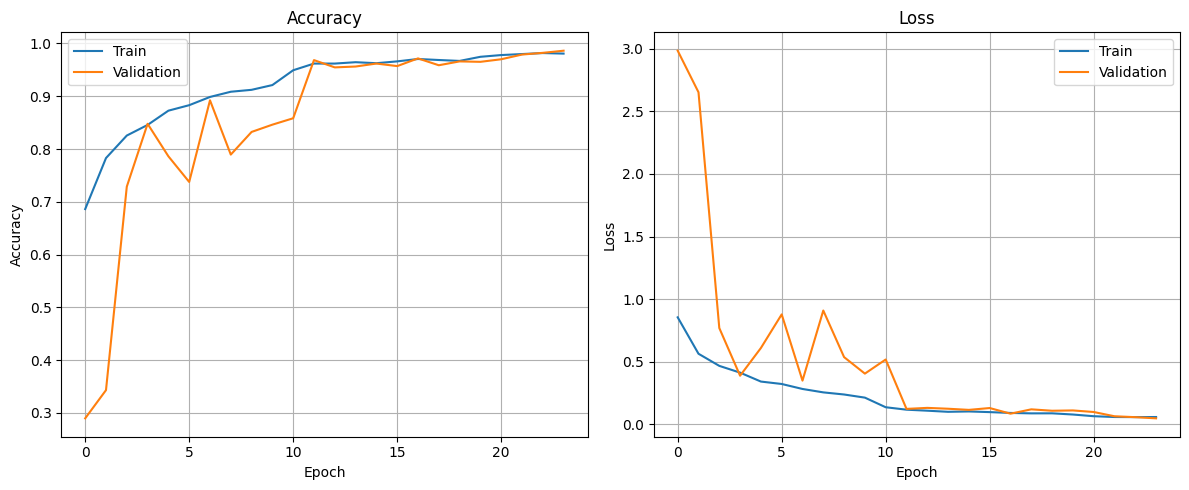

In [ ]:
# Plotting A single Graph containing both Accuracy(Training and Validation) and Loss(Training and Validation) Graphs:

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# SECTION 5: TEST GENERATOR (For evaluation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/03_test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False                # CRITICAL: Keep it false while Evaluation 
)

Found 1235 images belonging to 4 classes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating model on test dataset...")

# 1. Finding Prediction over Test Images:
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

Evaluating model on test dataset...
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step


In [ ]:
# 2. True (Original) labels Finding :
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
#  SECTION A: OVERALL TEST ACCURACY : Overall evaluation on complete Dataset
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print("\n" + "="*50)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")
print("="*50 + "\n")


Final Test Accuracy: 98.38%
Final Test Loss:     0.0398



In [ ]:
# SECTION B: PRECISION, RECALL, F1-SCORE 
print("Classification Report (Class-wise Performance):")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Classification Report (Class-wise Performance):
                             precision    recall  f1-score   support

       Tomato___Late_blight       0.98      0.98      0.98       327
         Tomato___Leaf_Mold       1.00      0.96      0.98       282
Tomato___Septoria_leaf_spot       0.98      0.99      0.98       319
           Tomato___healthy       0.98      1.00      0.99       307

                   accuracy                           0.98      1235
                  macro avg       0.98      0.98      0.98      1235
               weighted avg       0.98      0.98      0.98      1235



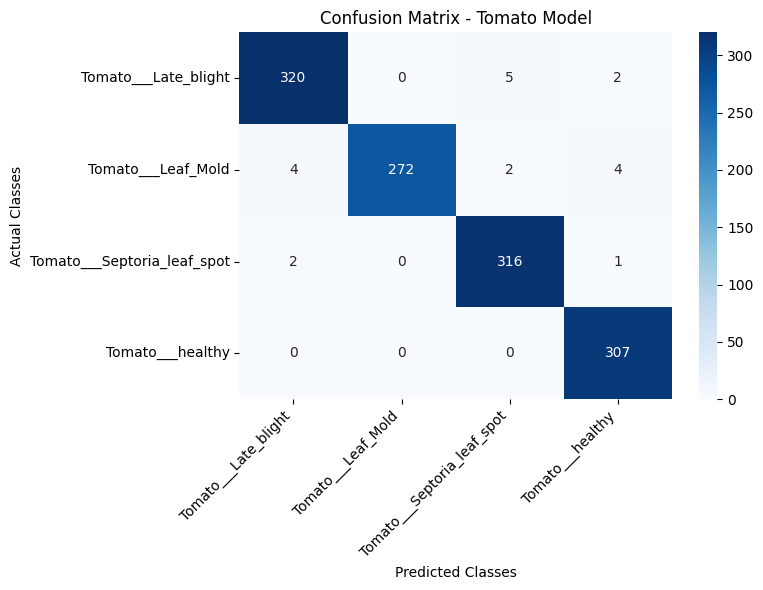

In [ ]:
# SECTION C: CONFUSION MATRIX 
# This will make us clear that which plant is getting confused with which different disease

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix - Tomato Model')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()